In [533]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,confusion_matrix,recall_score,precision_score,f1_score,roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.decomposition import PCA

In [534]:
df=pd.read_csv('insurance_claims.csv')

In [535]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [536]:
df.shape

(1000, 40)

In [537]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [538]:
df['fraud_reported'].value_counts()

fraud_reported
N    753
Y    247
Name: count, dtype: int64

# EDA

In [539]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.00,-51500.0000,-23250.0,0.000,0.00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.00,6.0000,12.0,17.000,23.00


In [540]:
df.describe(include='object').T

,count,unique,top,freq
policy_bind_date,1000,951,2006-01-01,3
policy_state,1000,3,OH,352
policy_csl,1000,3,250/500,351
insured_sex,1000,2,FEMALE,537
insured_education_level,1000,7,JD,161
insured_occupation,1000,14,machine-op-inspct,93
insured_hobbies,1000,20,reading,64
insured_relationship,1000,6,own-child,183
incident_date,1000,60,2015-02-02,28
incident_type,1000,4,Multi-vehicle Collision,419


In [541]:
df.isnull().sum()

months_as_customer                0
age                               0
policy_number                     0
policy_bind_date                  0
policy_state                      0
policy_csl                        0
policy_deductable                 0
policy_annual_premium             0
umbrella_limit                    0
insured_zip                       0
insured_sex                       0
insured_education_level           0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
capital-gains                     0
capital-loss                      0
incident_date                     0
incident_type                     0
collision_type                    0
incident_severity                 0
authorities_contacted            91
incident_state                    0
incident_city                     0
incident_location                 0
incident_hour_of_the_day          0
number_of_vehicles_involved       0
property_damage             

In [542]:
df.duplicated().sum()

np.int64(0)

In [543]:
df.nunique().sort_values(ascending=False)

policy_number                  1000
incident_location              1000
insured_zip                     995
policy_annual_premium           991
policy_bind_date                951
total_claim_amount              763
vehicle_claim                   726
injury_claim                    638
property_claim                  626
months_as_customer              391
capital-loss                    354
capital-gains                   338
incident_date                    60
age                              46
auto_model                       39
incident_hour_of_the_day         24
auto_year                        21
insured_hobbies                  20
insured_occupation               14
auto_make                        14
umbrella_limit                   11
insured_education_level           7
incident_state                    7
incident_city                     7
insured_relationship              6
witnesses                         4
incident_severity                 4
number_of_vehicles_involved 

In [544]:
df['fraud_reported'].value_counts(normalize=True)*100

fraud_reported
N    75.3
Y    24.7
Name: proportion, dtype: float64

<Axes: xlabel='fraud_reported'>

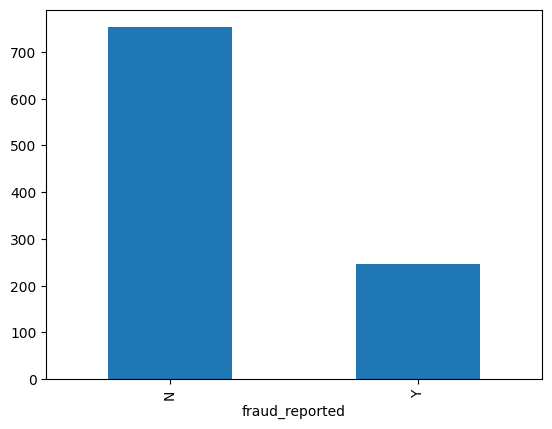

In [545]:
df['fraud_reported'].value_counts().plot(kind='bar')

<Axes: xlabel='fraud_reported', ylabel='count'>

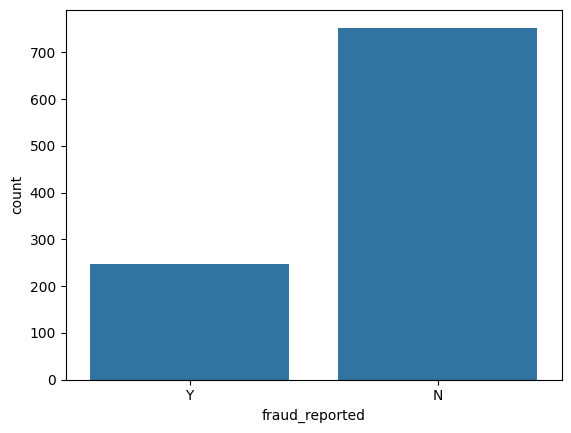

In [546]:
sns.countplot(x='fraud_reported',data=df)

In [547]:
pd.crosstab(df['incident_type'],
           df['fraud_reported'],
            normalize='index')*100

fraud_reported,N,Y
incident_type,,
Multi-vehicle Collision,72.792363,27.207637
Parked Car,90.476190,9.523810
Single Vehicle Collision,70.967742,29.032258
Vehicle Theft,91.489362,8.510638


In [548]:
pd.crosstab(df['incident_severity'],
           df['fraud_reported'],
           normalize='index')*100

fraud_reported,N,Y
incident_severity,,
Major Damage,39.492754,60.507246
Minor Damage,89.265537,10.734463
Total Loss,87.142857,12.857143
Trivial Damage,93.333333,6.666667


In [549]:
pd.crosstab(df['collision_type'],
           df['fraud_reported'],
           normalize='index')*100

fraud_reported,N,Y
collision_type,,
?,91.011236,8.988764
Front Collision,72.440945,27.559055
Rear Collision,68.835616,31.164384
Side Collision,74.637681,25.362319


In [550]:
pd.crosstab(df['property_damage'],
           df['fraud_reported'],
           normalize='index')*100

fraud_reported,N,Y
property_damage,,
?,71.388889,28.611111
NO,80.473373,19.526627
YES,74.172185,25.827815


In [551]:
pd.crosstab(df['police_report_available'],
           df['fraud_reported'],
           normalize='index')*100

fraud_reported,N,Y
police_report_available,,
?,74.052478,25.947522
NO,74.927114,25.072886
YES,77.070064,22.929936


In [552]:
df['property_damage'].value_counts(dropna=False)

property_damage
?      360
NO     338
YES    302
Name: count, dtype: int64

In [553]:
df['police_report_available'].value_counts(dropna=False)

police_report_available
?      343
NO     343
YES    314
Name: count, dtype: int64

In [554]:
df['property_damage']=df['property_damage'].replace('?','Unknown')

In [555]:
df['police_report_available']=df['police_report_available'].replace('?','Unknown')

In [556]:
df.columns

Index(['months_as_customer', 'age', 'policy_number', 'policy_bind_date',
       'policy_state', 'policy_csl', 'policy_deductable',
       'policy_annual_premium', 'umbrella_limit', 'insured_zip', 'insured_sex',
       'insured_education_level', 'insured_occupation', 'insured_hobbies',
       'insured_relationship', 'capital-gains', 'capital-loss',
       'incident_date', 'incident_type', 'collision_type', 'incident_severity',
       'authorities_contacted', 'incident_state', 'incident_city',
       'incident_location', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', '_c39'],
      dtype='object')

In [557]:
df.groupby('fraud_reported')[[
    'age',
    'months_as_customer',
    'policy_annual_premium',
    'total_claim_amount',
    'injury_claim',
    'property_claim',
    'vehicle_claim'
]].mean().round(2)

,age,months_as_customer,policy_annual_premium,total_claim_amount,injury_claim,property_claim,vehicle_claim
fraud_reported,,,,,,,
N,38.88,202.60,1258.43,50288.61,7179.23,7018.88,36090.49
Y,39.14,208.08,1250.24,60302.11,8208.34,8560.12,43533.64


In [558]:
cols=['total_claim_amount','vehicle_claim','property_claim','injury_claim']

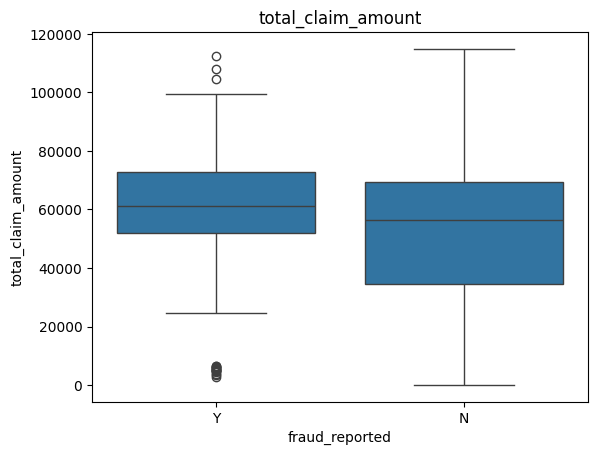

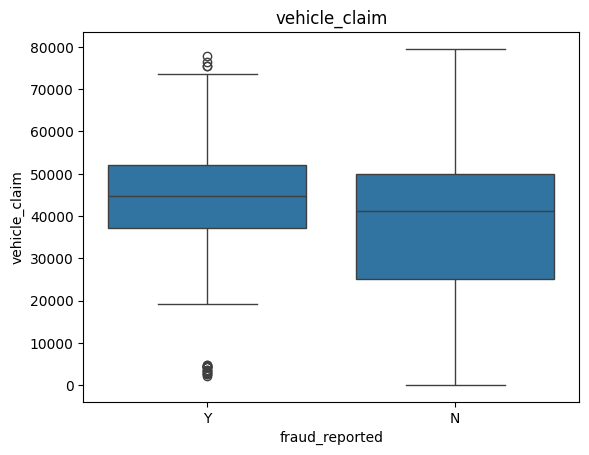

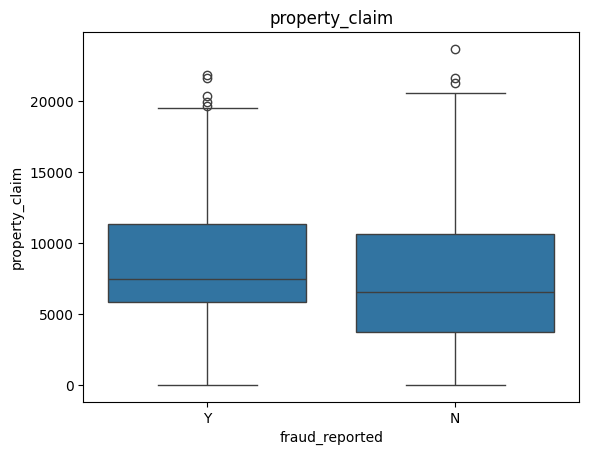

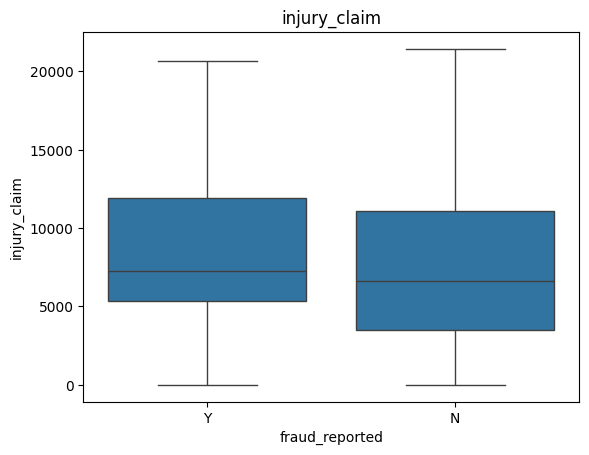

In [559]:
for col in cols:
    sns.boxplot(x='fraud_reported',y=col,data=df)
    plt.title(col)
    plt.show()

In [560]:
drop_cols=['_c39',
     'policy_number',
     'incident_location',
     'insured_zip']

In [561]:
df.drop(columns=drop_cols,inplace=True)

In [562]:
df['policy_bind_date']=pd.to_datetime(df['policy_bind_date'])

In [563]:
df['incident_date']=pd.to_datetime(df['incident_date'])

In [564]:
df['collision_type']=df['collision_type'].replace('?','Unknown')

In [565]:
df['authorities_contacted']=df['authorities_contacted'].fillna('Unknown')

In [566]:
df['fraud_reported']=df['fraud_reported'].map({'Y':1,'N':0})

# Feature Engineering

In [567]:
df['policy_duration_day']=(df['incident_date']-df['policy_bind_date']).dt.days

In [568]:
df['Vehicle_age']=pd.Timestamp.now().year-df['auto_year']

In [569]:
df['claim_per_vehicle_age']=(df['total_claim_amount']/(df['Vehicle_age'])+1)

In [570]:
df['property_claim_ratio']=(df['property_claim']/df['total_claim_amount'])

In [571]:
df['Vehicle_claim_ratio']=(df['vehicle_claim']/df['total_claim_amount'])

In [572]:
df['claim_per_vehicle']=df['total_claim_amount']/df['number_of_vehicles_involved']

In [573]:
df['injury_claim_ratio']=(df['injury_claim']/df['total_claim_amount'])

In [574]:
new_feature=[
    'policy_duration_day',
    'Vehicle_age',
    'claim_per_vehicle_age',
    'injury_claim_ratio',
    'property_claim_ratio',
    'Vehicle_claim_ratio',
    'claim_per_vehicle',
]

In [575]:
df[new_feature].describe().T

,count,mean,std,min,25%,50%,75%,max
policy_duration_day,1000.0,4739.140000,2686.430702,-20.000000,2484.000000,4682.000000,7068.000000,9172.000000
Vehicle_age,1000.0,20.897000,6.015861,11.000000,16.000000,21.000000,26.000000,31.000000
claim_per_vehicle_age,1000.0,2753.830823,1674.006244,5.166667,1742.865217,2665.692308,3804.333333,9862.818182
injury_claim_ratio,1000.0,0.139241,0.050661,0.000000,0.100000,0.125000,0.181818,0.300000
property_claim_ratio,1000.0,0.138648,0.048644,0.000000,0.100000,0.125000,0.181818,0.333333
Vehicle_claim_ratio,1000.0,0.722112,0.061271,0.555556,0.692308,0.727273,0.777778,1.000000
claim_per_vehicle,1000.0,35705.954167,26693.529712,100.000000,15490.000000,25355.000000,58170.000000,112320.000000


In [576]:
df[new_feature].corr().round(2)

,policy_duration_day,Vehicle_age,claim_per_vehicle_age,injury_claim_ratio,property_claim_ratio,Vehicle_claim_ratio,claim_per_vehicle
policy_duration_day,1.00,0.01,-0.02,0.01,0.01,-0.02,0.01
Vehicle_age,0.01,1.00,-0.47,-0.03,-0.04,0.06,0.06
claim_per_vehicle_age,-0.02,-0.47,1.00,0.07,0.06,-0.10,0.53
injury_claim_ratio,0.01,-0.03,0.07,1.00,-0.24,-0.64,0.02
property_claim_ratio,0.01,-0.04,0.06,-0.24,1.00,-0.60,0.03
Vehicle_claim_ratio,-0.02,0.06,-0.10,-0.64,-0.60,1.00,-0.05
claim_per_vehicle,0.01,0.06,0.53,0.02,0.03,-0.05,1.00


In [577]:
(df['policy_duration_day']<0).sum()

np.int64(1)

In [578]:
df=df[df['policy_duration_day']>=0]

In [579]:
num_df=df.select_dtypes('int64','float64')

In [580]:
num_df.corr()['fraud_reported'].sort_values(ascending=False)

fraud_reported                 1.000000
vehicle_claim                  0.170001
total_claim_amount             0.163642
property_claim                 0.137913
injury_claim                   0.091040
umbrella_limit                 0.058363
number_of_vehicles_involved    0.051938
witnesses                      0.050333
bodily_injuries                0.033888
months_as_customer             0.021635
policy_deductable              0.014693
age                            0.012978
auto_year                      0.007729
incident_hour_of_the_day       0.004594
policy_duration_day           -0.000087
Vehicle_age                   -0.007729
capital-loss                  -0.014325
capital-gains                 -0.018663
Name: fraud_reported, dtype: float64

In [581]:
df.columns

Index(['months_as_customer', 'age', 'policy_bind_date', 'policy_state',
       'policy_csl', 'policy_deductable', 'policy_annual_premium',
       'umbrella_limit', 'insured_sex', 'insured_education_level',
       'insured_occupation', 'insured_hobbies', 'insured_relationship',
       'capital-gains', 'capital-loss', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'authorities_contacted',
       'incident_state', 'incident_city', 'incident_hour_of_the_day',
       'number_of_vehicles_involved', 'property_damage', 'bodily_injuries',
       'witnesses', 'police_report_available', 'total_claim_amount',
       'injury_claim', 'property_claim', 'vehicle_claim', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', 'policy_duration_day',
       'Vehicle_age', 'claim_per_vehicle_age', 'property_claim_ratio',
       'Vehicle_claim_ratio', 'claim_per_vehicle', 'injury_claim_ratio'],
      dtype='object')

In [582]:
col=['policy_bind_date','incident_date','auto_year']

In [583]:
df.drop(columns=col,inplace=True)

In [584]:
x=df.drop(['fraud_reported'],axis=1)
y=df['fraud_reported']

In [585]:
cat_col=x.select_dtypes('object').columns.tolist()

In [586]:
len(cat_col)

17

In [587]:
num_col=x.select_dtypes(exclude='object').columns.tolist()

In [588]:
len(num_col)

22

In [589]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [590]:
preprocessor=ColumnTransformer(
    transformers=[
        ('cat',OneHotEncoder(handle_unknown='ignore'),cat_col),
        ('num',StandardScaler(),num_col)
    ]
)

# Model-1 Logistic Regression

In [591]:
logistic_pipeline=Pipeline([
    ('Preprocessor',preprocessor),
    ('Model',LogisticRegression(
        max_iter=1000
    ))
])

In [592]:
logistic_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('Preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['months_as_customer','age','policy_state',...,'Vehicle_claim_ratio', 'claim_per_vehicle','injury_claim_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [593]:
y_pred1=logistic_pipeline.predict(x_test)

In [594]:
y_prob1=logistic_pipeline.predict_proba(x_test)[:,1]

In [595]:
print("Accuracy :", accuracy_score(y_test, y_pred1))
print("Precision:", precision_score(y_test, y_pred1))
print("Recall   :", recall_score(y_test, y_pred1))
print("F1 Score :", f1_score(y_test, y_pred1))
print("ROC AUC  :", roc_auc_score(y_test, y_prob1))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.845
Precision: 0.78125
Recall   : 0.5102040816326531
F1 Score : 0.6172839506172839
ROC AUC  : 0.8357886200837951

Confusion Matrix:
[[150   1]
 [ 44   5]]


# Model-2 KNN

In [596]:
knn_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('Model',KNeighborsClassifier(
        n_neighbors=5
    ))
])

In [597]:
knn_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['months_as_customer','age','policy_state',...,'Vehicle_claim_ratio', 'claim_per_vehicle','injury_claim_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [598]:
y_pred=knn_pipeline.predict(x_test)

In [599]:
y_prob=knn_pipeline.predict_proba(x_test)[:,1]

In [600]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.745
Precision: 0.45
Recall   : 0.1836734693877551
F1 Score : 0.2608695652173913
ROC AUC  : 0.6911744830382484

Confusion Matrix:
[[140  11]
 [ 40   9]]


# Model-3 Gaaussian Naive Bayse 

In [601]:
preprocessor_nb=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),num_col),
        ('cat',OneHotEncoder(handle_unknown='ignore',sparse_output=False),cat_col)
    ]
)

In [602]:
naive_pipeline=Pipeline([
    ('preprocessor',preprocessor_nb),
    ('Model',GaussianNB())
])

In [603]:
naive_pipeline.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['months_as_customer','age','policy_state',...,'Vehicle_claim_ratio', 'claim_per_vehicle','injury_claim_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [604]:
y_pred=naive_pipeline.predict(x_test)

In [605]:
y_prob=naive_pipeline.predict_proba(x_test)[:,1]

In [606]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.62
Precision: 0.3333333333333333
Recall   : 0.5510204081632653
F1 Score : 0.4153846153846154
ROC AUC  : 0.6439383700500068

Confusion Matrix:
[[97 54]
 [22 27]]


# Model-4 SVM RBF

In [607]:
svm_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('Model',SVC(
        kernel='rbf',
        C=1,
        gamma='scale',
        probability=True,
        random_state=42
    ))
])

In [608]:
svm_pipeline.fit(x_train,y_train)

C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['months_as_customer','age','policy_state',...,'Vehicle_claim_ratio', 'claim_per_vehicle','injury_claim_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [609]:
y_pred=svm_pipeline.predict(x_test)

In [610]:
y_prob=svm_pipeline.predict_proba(x_test)[:,1]

In [611]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.76
Precision: 0.6
Recall   : 0.061224489795918366
F1 Score : 0.1111111111111111
ROC AUC  : 0.8499797269901338

Confusion Matrix:
[[149   2]
 [ 46   3]]


# Model-5 SVM Linear

In [612]:
svm_linear_pipeline=Pipeline([
    ('preprocessor',preprocessor),
    ('Model',SVC(
        kernel='linear',
        probability=True
    ))
])

In [613]:
svm_linear_pipeline.fit(x_train,y_train)

C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['months_as_customer','age','policy_state',...,'Vehicle_claim_ratio', 'claim_per_vehicle','injury_claim_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [614]:
y_pred=svm_linear_pipeline.predict(x_test)

In [615]:
y_prob=svm_linear_pipeline.predict_proba(x_test)[:,1]

In [616]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.83
Precision: 0.7142857142857143
Recall   : 0.5102040816326531
F1 Score : 0.5952380952380952
ROC AUC  : 0.7992972023246383

Confusion Matrix:
[[141  10]
 [ 24  25]]


# PCA

In [617]:
x_train_transformed=preprocessor.fit_transform(x_train)

In [618]:
x_train_transformed.shape

(799, 167)

In [619]:
pca=PCA()

In [620]:
pca.fit(x_train_transformed)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [621]:
cum_var=np.cumsum(pca.explained_variance_ratio_)

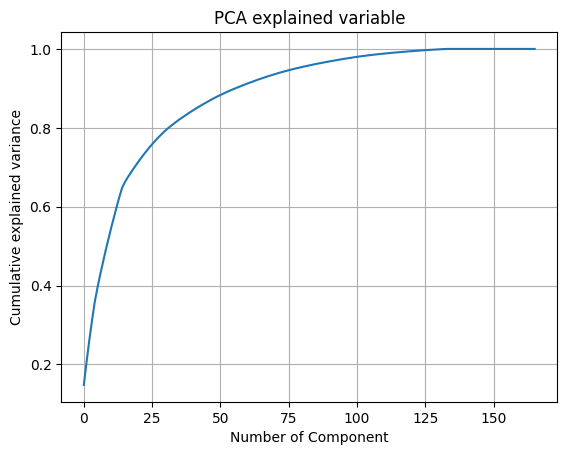

In [622]:
plt.plot(cum_var)
plt.xlabel('Number of Component')
plt.ylabel('Cumulative explained variance')
plt.title('PCA explained variable')
plt.grid()

In [623]:
n_component=np.argmax(cum_var>=0.95)+1

In [624]:
print("Components for 95% variance:", n_component)

Components for 95% variance: 79


# Model-6 PCA + SVM

In [625]:
pca_svm=Pipeline([
    ('preprocessor',preprocessor),
    ('pca',PCA(n_components=79)),
    ('Model',SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ))
])

In [626]:
pca_svm.fit(x_train,y_train)

C:\Users\kunal\anaconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('pca', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](39,)","['months_as_customer','age','policy_state',...,'Vehicle_claim_ratio', 'claim_per_vehicle','injury_claim_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,39
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By s

In [627]:
y_pred=pca_svm.predict(x_test)

In [628]:
y_prob=pca_svm.predict_proba(x_test)[:,1]

In [629]:
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.775
Precision: 0.8333333333333334
Recall   : 0.10204081632653061
F1 Score : 0.18181818181818182
ROC AUC  : 0.8211920529801324

Confusion Matrix:
[[150   1]
 [ 44   5]]


In [630]:
cv_score=cross_val_score(
    logistic_pipieline,
    x,
    y,
    cv=5,
   scoring='f1'
 )

In [631]:
print("CV Scores:", cv_score)
print("Mean CV F1:", cv_score.mean())
print("Std CV F1 :", cv_score.std())

CV Scores: [0.63043478 0.52747253 0.54347826 0.63043478 0.72727273]
Mean CV F1: 0.6118186161664422
Std CV F1 : 0.07184349924303368


# Model comparison

In [632]:
comparison = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'KNN',
        'Naive Bayes',
        'RBF SVM',
        'Linear SVM',
        'PCA + SVM'
    ],
    'Accuracy':[0.845,0.745,0.620,0.760,0.830,0.775],
    'Precision':[0.781,0.450,0.333,0.600,0.714,0.833],
    'Recall':[0.510,0.184,0.551,0.061,0.510,0.102],
    'F1':[0.617,0.261,0.415,0.111,0.595,0.182],
    'ROC_AUC':[0.836,0.691,0.644,0.850,0.799,0.821]
})


In [633]:
comparison = comparison.sort_values(
    by='F1',
    ascending=False
)

In [634]:
comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.845,0.781,0.510,0.617,0.836
4,Linear SVM,0.830,0.714,0.510,0.595,0.799
2,Naive Bayes,0.620,0.333,0.551,0.415,0.644
1,KNN,0.745,0.450,0.184,0.261,0.691
5,PCA + SVM,0.775,0.833,0.102,0.182,0.821
3,RBF SVM,0.760,0.600,0.061,0.111,0.850


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Logistic Regression'),
  Text(1, 0, 'Linear SVM'),
  Text(2, 0, 'Naive Bayes'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'PCA + SVM'),
  Text(5, 0, 'RBF SVM')])

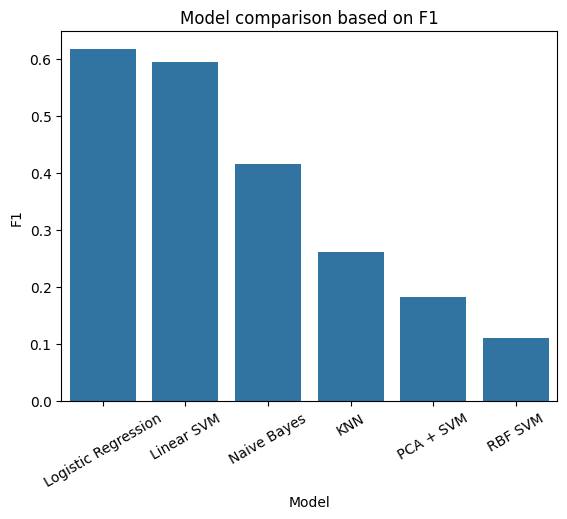

In [635]:
sns.barplot(
    data=comparison,
    x='Model',
    y='F1'
)
plt.title('Model comparison based on F1')
plt.xticks(rotation=30)

In [636]:
import joblib

In [637]:
joblib.dump(
    logistic_pipieline,
    'insurance_fraud_model.pkl'
)

['insurance_fraud_model.pkl']